<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB32 · Actor-crítico: dos redes que aprenden juntas

**Parte 4 · Aprendizaje por refuerzo de verdad — Lección 5**

> Hasta ahora, el palo de escoba ha aprendido con una política **diminuta**: una neurona con dos ruedecillas (NB29), y un crítico hecho **a mano** con cinco rasgos
> que elegimos nosotros (NB30), que encima resultó bastante tosco. En el NB31 conociste **PyTorch**, la herramienta que calcula sola las pendientes de cualquier red.

Hoy juntamos las dos cosas. Vamos a construir el algoritmo que está en el corazón de casi todo el aprendizaje por refuerzo moderno para robots: el
**actor-crítico**, con **dos redes neuronales**:

- el **actor**, una red que decide qué hacer (la política, con su campana de acciones);
- el **crítico**, otra red que aprende **cuánto vale** cada situación.

Y aprenderás una idea nueva y preciosa, la **diferencia temporal**: cómo el crítico permite juzgar una acción **sin esperar a que acabe el episodio**.

Como siempre, primero entenderemos todo con palabras y dibujos. El código llegará cuando las piezas estén claras.


## 1 · La idea, sin código: el jugador y el comentarista

Imagina un partido de tenis. Hay dos personas:

- **El jugador** (el **actor**). En cada momento mira la situación (dónde está la pelota, dónde está el rival) y **decide** un golpe. No es perfecto: a veces prueba
  golpes un poco distintos (la campana de acciones del NB28, la **exploración**).
- **El comentarista** (el **crítico**). No juega. Mira la situación y dice **cómo pinta la cosa**: "esta posición es muy buena para el jugador", "uf, aquí lo tiene
  difícil". Es decir, **predice** cuántos puntos se van a ganar desde ahí.

¿Cómo aprende el jugador? Después de cada golpe, compara lo que pasó con lo que el comentarista esperaba:

- Si el comentarista decía "esto pinta regular" y, tras el golpe, la cosa salió **mejor de lo esperado**, ese golpe merece **reforzarse**.
- Si salió **peor de lo esperado**, ese golpe merece **debilitarse**.

Eso que "salió mejor o peor de lo esperado" es exactamente la **ventaja** del NB29-30. Y el comentarista es el **crítico** del NB30, solo que ahora será una red.

¿Y cómo aprende el comentarista? Comparando sus predicciones con lo que **de verdad** pasó, y corrigiéndose. Es aprendizaje **supervisado**, como la imitación del NB18: tiene un
"maestro" (lo que realmente ocurrió) y reduce su error cuadrático.

```
            situación (observación)
             │                 │
             ▼                 ▼
      ┌────────────┐    ┌──────────────┐
      │   ACTOR    │    │   CRÍTICO    │
      │ (red: qué  │    │ (red: cuánto │
      │  hacer)    │    │  vale esto)  │
      └─────┬──────┘    └──────┬───────┘
            │ acción           │ "espero tanto"
            ▼                  │
        el mundo  ──► lo que pasó de verdad
                               │
                               ▼
              ventaja = lo que pasó − lo que se esperaba
                               │
            ┌──────────────────┴──────────────────┐
            ▼                                     ▼
   el actor refuerza o debilita        el crítico corrige su predicción
       la acción (NB29)                  (error cuadrático, NB18)
```

Los dos aprenden **a la vez**, cada uno con su propia red, sus propias ruedecillas y su propio optimizador. El actor mejora gracias al crítico, y el crítico tiene que ir siguiendo
a un actor que cambia. Es como un baile en pareja.


## 2 · ¿Por qué redes, si la neurona ya funcionaba?

Buena pregunta. En el NB29 la política era `empuje = w1 × inclinación + w2 × velocidad`: una **línea recta**. Para el palo de escoba basta, porque la buena política es casi una
recta. Pero:

1. **El mundo real no es recto.** El empuje tiene un **límite** (±40). Cuando el palo está muy inclinado, lo sensato es empujar "a tope" y no más; una recta no sabe "saturar"
   (recuerda el maestro que satura del NB19). Y en un humanoide, la relación entre lo que ve el robot (348 números) y lo que hace (17 motores) es enrevesadísima. Solo una red
   puede aprenderla.
2. **El crítico lineal era tosco.** En el NB30 tuvimos que **inventar** los rasgos (i², v², i·v, el tiempo...) y aun así predecía disparates (como −231 para una situación
   normal). Con una red, **no hay que inventar rasgos**: la red los descubre sola en su capa oculta (NB19). Esa es la gran ventaja de las redes: aprenden **las propias
   características** que necesitan.

El precio: más ruedecillas, y un aprendizaje algo más delicado. Ya lo verás.


## 3 · El truco de la pérdida del actor

Aquí hay un pequeño problema de encaje. PyTorch está pensado para **bajar** una **pérdida** (NB31): `perdida.backward()` y luego `optimizador.step()` mueve las ruedecillas cuesta
**abajo**. Pero en el NB29 nosotros no teníamos una pérdida: teníamos una **dirección de mejora** que había que **subir**:

```
dirección de mejora = media de  [ ventaja × (pendiente de la log-probabilidad de la acción) ]
```

¿Cómo se lo explicamos a PyTorch? Con un truco muy sencillo. Fabricamos un número, la **pérdida del actor**:

```
pérdida del actor = − media de [ log-probabilidad de la acción × ventaja ]
```

y le pedimos a PyTorch que la **baje**. Fíjate en lo que pasa:

- La ventaja es solo un **número fijo** para cada acción (no depende de las ruedecillas del actor; lo calculó el crítico). Así que la pendiente de "log-prob × ventaja"
  es "ventaja × pendiente de la log-prob": **exactamente** lo que había dentro de la dirección de mejora.
- El signo **menos** hace que **bajar** esa pérdida sea lo mismo que **subir** la dirección de mejora. (Bajar −x es subir x.)

Así de simple: no es una pérdida "de verdad" (su valor no significa nada útil, no hay que mirarlo), es un **truco para que la pendiente salga la que queremos**. Lo usan todas las
implementaciones de REINFORCE, actor-crítico y PPO del mundo.

Y piensa en qué hace con cada acción:

- Ventaja **positiva** (salió mejor de lo esperado): bajar la pérdida = **subir** su log-probabilidad → la acción se vuelve más probable.
- Ventaja **negativa**: bajar la pérdida = **bajar** su log-probabilidad → la acción se vuelve menos probable.

Comprobémoslo con números antes de seguir. Como en el NB31, una política lineal con pesos (−5, −3), la observación (2, 1), σ = 5, la acción −10... y ahora una ventaja de +2:


In [1]:
import torch
from torch import nn
from torch.distributions import Normal
import numpy as np
import matplotlib.pyplot as plt

pesos = torch.tensor([-5.0, -3.0], requires_grad=True)
observacion = torch.tensor([2.0, 1.0])
accion = torch.tensor(-10.0)
ventaja = 2.0
sigma = 5.0

media = observacion @ pesos
perdida_actor = -Normal(media, sigma).log_prob(accion) * ventaja
perdida_actor.backward()

print("pendiente de la pérdida (PyTorch):", pesos.grad)
print("− ventaja × (a − μ)/σ² × obs (NB29):", -ventaja * (accion - media.detach()) / sigma ** 2 * observacion)


pendiente de la pérdida (PyTorch): tensor([-0.4800, -0.2400])
− ventaja × (a − μ)/σ² × obs (NB29): tensor([-0.4800, -0.2400])


Iguales. Y como el optimizador da el paso **contrario** a la pendiente de la pérdida (cuesta abajo), el paso real va en la dirección **+ ventaja × (a − μ)/σ² × obs**: la del NB29.
La media era −13 y la acción, −10 (un poco más arriba); con ventaja positiva, los pesos se moverán para que la media suba hacia −10. **Esta acción salió bien: hazla más probable.**


## 4 · Dos detalles prácticos antes de construir

### Escalar las entradas

Las redes neuronales aprenden mucho mejor cuando los números que les entran son **pequeños**, más o menos entre −1 y 1 (como la normalización del NB27). Nuestra inclinación va de −30 a
30 grados, y la velocidad de giro anda por las decenas. Así que, antes de meterlas en la red, las **dividimos** por una escala: la inclinación entre 10 y la velocidad entre 20. No cambia
la información, solo la "unidad de medida", y le ahorra a la red un buen dolor de cabeza.

Por la misma razón, la **acción** del actor estará **normalizada**, entre −1 y 1, como en el entorno oficial del NB25: luego se multiplica por 40 para obtener el empuje.

### σ como ruedecilla: el robot aprende cuánto explorar

En el NB29 la anchura de la campana, σ, era fija. Elegirla bien era un arte (NB28: con σ demasiado grande el palo se cae; demasiado pequeña, no se explora). ¿Por qué no dejar que la
**aprenda**? Al principio conviene explorar mucho; al final, cuando ya sabe, conviene afinar.

El problema: σ **tiene que ser positiva** (una campana de anchura −2 no existe). Si la dejamos como ruedecilla libre, un paso de aprendizaje podría hacerla negativa y todo explotaría. El truco
habitual: la ruedecilla no es σ, sino su **logaritmo** (NB28), **log σ**, que puede valer cualquier cosa, positiva o negativa. Y cuando necesitamos σ, la recuperamos con la
**exponencial**: σ = e^(log σ), que **siempre** es positiva:

| log σ | σ = e^(log σ) |
|---|---|
| −3 | 0,05 |
| −1,39 | 0,25 |
| 0 | 1 |
| 1 | 2,72 |

Sea cual sea el valor de la ruedecilla, σ sale positiva. ¡Problema resuelto con una función que ya conocías!


## 5 · La idea nueva: la diferencia temporal

Hasta ahora, para saber si una acción fue buena, esperábamos **al final del episodio** y sumábamos todas las recompensas desde ese paso: el **retorno** G (NB29). A esa forma de juzgar
se le llama **Montecarlo** (como el casino: se juega la partida entera y se mira el resultado).

Pero piensa en un viaje en coche con GPS. Sales de casa y el GPS dice "llegada estimada: 45 minutos". Diez minutos después, tras pillar un atasco, dice "llegada estimada: 50 minutos".
¿Hace falta **llegar** para saber que el atasco te ha perjudicado? **No.** En diez minutos has gastado 10, y te quedan 50 según la nueva estimación: total 60, frente a los 45 que se
esperaban. Ese tramo salió **15 minutos peor de lo esperado**, y lo sabes **ya**, sin esperar al final.

Eso es la **diferencia temporal** (en inglés, *temporal difference*, **TD**). Con el crítico podemos hacer lo mismo con el palo de escoba. Tras dar un paso:

```
δ  =   r       +   γ × V(situación siguiente)   −   V(situación de ahora)
      ─┬─          ──────────┬──────────────        ───────┬────────
  lo que ganaste    lo que el crítico espera          lo que el crítico
  en este paso      desde donde has llegado          esperaba antes del paso
```

(δ es la letra griega **delta**, la "d" griega, y se usa mucho para "diferencia".) Si δ es positiva, el paso salió **mejor de lo esperado**; si es negativa, **peor**. Es una ventaja,
pero calculada mirando **un solo paso** hacia delante y fiándose del crítico para todo lo demás. Y un detalle: si el palo se ha **caído** en ese paso, no hay "situación siguiente": su
valor es 0.

### ¿Qué se gana y qué se pierde?

- **Montecarlo** (G − V): usa lo que pasó de verdad hasta el final. Es **honesto** (sin errores del crítico), pero tiene **mucho ruido**: el retorno de un paso depende del viento de
  los cientos de pasos siguientes, que no tienen nada que ver con la acción (NB30).
- **Diferencia temporal** (δ): solo usa **una** recompensa de verdad y luego se fía del crítico. Tiene **mucho menos ruido** (solo un paso de viento al azar), pero si el crítico se equivoca,
  la ventaja hereda su error. A ese error sistemático se le llama **sesgo**.

Es un **equilibrio entre ruido y sesgo**, una de las ideas más importantes de todo el aprendizaje por refuerzo. (En la próxima lección verás un "mando" que permite elegir cualquier punto
intermedio entre los dos extremos.) Hoy probaremos ambos y **mediremos** cuál funciona mejor aquí.

### Un detalle: el reloj

Nuestros episodios se **cortan** a los 500 pasos aunque el palo siga de pie (NB25: truncar). Por eso, una misma inclinación vale más en el paso 10 (quedan 490 pasos de recompensas) que en
el paso 490 (quedan 10). Como en el NB30, le daremos al crítico, además de la inclinación y la velocidad, **el reloj**: en qué paso estamos (dividido entre 500 para que quede entre 0 y 1).
El actor no lo necesita: mantener el palo derecho se hace igual al principio que al final.


## 6 · Construimos el actor

Ya tenemos todas las piezas. El **actor** es una clase que hereda de `nn.Module` (NB25, NB31), con:

- una pequeña red: 2 entradas (inclinación y velocidad, escaladas) → 32 neuronas ocultas → 1 salida (la **media** de la campana);
- una ruedecilla suelta, **`log_sigma`**, que empieza en log(0,25): una campana de anchura 0,25, es decir, ±10 de empuje (0,25 × 40).

Dos novedades de PyTorch:

- **`nn.Tanh()`**: otra función de activación, como el ReLU del NB19, pero con forma de **S suave**: aplasta cualquier número al intervalo entre −1 y 1. Se usa mucho en redes
  pequeñas de control porque es suave (no tiene "codo").
- **`nn.Parameter(...)`**: convierte un tensor en una **ruedecilla oficial** de la red. Así aparece en `actor.parameters()` y el optimizador la moverá junto con las demás.


In [2]:
ESCALA = torch.tensor([10.0, 20.0])          # inclinación / 10, velocidad / 20

class Actor(nn.Module):
    def __init__(self, ocultas=32, sigma_inicial=0.25):
        super().__init__()
        self.red = nn.Sequential(nn.Linear(2, ocultas), nn.Tanh(), nn.Linear(ocultas, 1))
        self.log_sigma = nn.Parameter(torch.tensor(np.log(sigma_inicial), dtype=torch.float32))

    def media(self, observaciones):
        return self.red(observaciones / ESCALA).squeeze(-1)

    def campana(self, observaciones):
        return Normal(self.media(observaciones), self.log_sigma.exp())

torch.manual_seed(0)
actor_prueba = Actor()
print(actor_prueba)
print("Ruedecillas:", sum(p.numel() for p in actor_prueba.parameters()))
print("σ inicial:", actor_prueba.log_sigma.exp().item())


Actor(
  (red): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)
Ruedecillas: 130
σ inicial: 0.25


`squeeze(-1)` quita la última dimensión, que mide 1 (la red da una tabla de forma (n, 1) y queremos un vector de n medias; es el contrario del `reshape(-1, 1)` del NB31).

**130 ruedecillas**: 2 × 32 + 32 (primera capa), 32 + 1 (segunda capa) y 1 más, `log_sigma`. Pidámosle la campana para un par de situaciones:


In [3]:
situaciones = torch.tensor([[2.0, 0.0], [-10.0, 5.0]])
campanas = actor_prueba.campana(situaciones)
print("medias:", campanas.mean)
print("sigma: ", campanas.stddev)
print("una acción sorteada para cada una:", campanas.sample())


medias: tensor([0.1260, 0.1155], grad_fn=<SqueezeBackward1>)
sigma:  tensor([0.2500, 0.2500], grad_fn=<ExpandBackward0>)
una acción sorteada para cada una: tensor([ 0.0385, -0.3680])


Las medias salen cerca de 0 (la red aún no sabe nada) y la σ, 0,25. `sample()` **sortea** una acción de cada campana (NB28). Este actor recién nacido es, básicamente, el azar.

## 7 · Construimos el crítico

El **crítico** es otra red: 3 entradas (inclinación, velocidad y reloj, escalados) → 64 neuronas ocultas → 1 salida, el **valor**. Un detalle: con el descuento γ = 0,99, el retorno de una situación
no pasa de 100 (sumar 1 + 0,99 + 0,99² + ... para siempre da exactamente 1/(1 − 0,99) = 100, NB30), pero a una red recién nacida le salen números de tamaño 1. Para que no tenga que aprender a sacar números enormes, multiplicamos su salida por 100 (como escalar las entradas, pero a la salida).


In [4]:
class Critico(nn.Module):
    def __init__(self, ocultas=64):
        super().__init__()
        self.red = nn.Sequential(nn.Linear(3, ocultas), nn.Tanh(), nn.Linear(ocultas, 1))
        self.escala = torch.tensor([10.0, 20.0, 500.0])     # inclinación, velocidad, paso

    def forward(self, entradas):
        return self.red(entradas / self.escala).squeeze(-1) * 100

critico_prueba = Critico()
print(critico_prueba)
print("Ruedecillas:", sum(p.numel() for p in critico_prueba.parameters()))
print("Valor de (2°, 0°/s, paso 0):", critico_prueba(torch.tensor([[2.0, 0.0, 0.0]])).item())


Critico(
  (red): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)
Ruedecillas: 321
Valor de (2°, 0°/s, paso 0): 7.696538925170898


**321 ruedecillas**, y su primera opinión es un disparate cualquiera (aún no ha aprendido nada). Ningún problema: aprenderá de los episodios.

## 8 · Jugar: el palo de escoba, muchos a la vez

Para aprender rápido, jugamos **muchos episodios a la vez**, vectorizados con NumPy, exactamente como en el NB29 (la misma física del palo, el mismo viento de ±30, la misma recompensa).
Solo cambian dos cosas:

1. La media de la campana la da **la red del actor**. Como solo estamos **jugando** (no calculando pendientes), lo hacemos dentro de `torch.no_grad()` (NB31).
2. La acción se sortea como en el NB29: **media + σ × un número de la campana estándar** (NB28), y el empuje es la acción, recortada entre −1 y 1, por 40.

Además, apuntamos todo (observaciones, acciones, recompensas y quién seguía vivo) en tablas de forma (pasos, episodios), y si todos los palos se han caído, paramos antes: no tiene sentido
seguir simulando palos en el suelo.


In [5]:
def jugar(actor, n_episodios, generador, pasos_maximos=500):
    inclinacion = np.full(n_episodios, 2.0)
    velocidad = np.zeros(n_episodios)
    vivos = np.ones(n_episodios, dtype=bool)
    observaciones = np.zeros((pasos_maximos, n_episodios, 2), dtype=np.float32)
    acciones = np.zeros((pasos_maximos, n_episodios), dtype=np.float32)
    recompensas = np.zeros((pasos_maximos, n_episodios), dtype=np.float32)
    estaba_vivo = np.zeros((pasos_maximos, n_episodios), dtype=bool)
    sigma = actor.log_sigma.exp().item()
    for t in range(pasos_maximos):
        observacion = np.stack([inclinacion, velocidad], axis=1).astype(np.float32)
        with torch.no_grad():
            media = actor.media(torch.from_numpy(observacion)).numpy()
        accion = media + sigma * generador.standard_normal(n_episodios)
        observaciones[t], acciones[t], estaba_vivo[t] = observacion, accion, vivos
        empuje = np.clip(accion, -1, 1) * 40
        aceleracion = 10 * inclinacion + empuje + generador.uniform(-30, 30, n_episodios)
        velocidad = velocidad + aceleracion * 0.02
        inclinacion = inclinacion + velocidad * 0.02
        vivos = vivos & (np.abs(inclinacion) <= 30)
        recompensas[t] = np.where(vivos, 1 - (inclinacion / 30) ** 2, 0.0)
        if not vivos.any():
            break
    return observaciones, acciones, recompensas, estaba_vivo


(`torch.from_numpy` convierte un array en tensor **sin copiarlo**, compartiendo la memoria: una **vista**, NB27. Es más rápido que `torch.tensor`.)

Probemos el actor recién nacido con 32 episodios:


In [6]:
generador = np.random.default_rng(0)
obs, acc, rec, vivo = jugar(actor_prueba, 32, generador)
retornos_episodio = (rec * vivo).sum(axis=0)
print(f"Retorno medio del actor sin entrenar: {retornos_episodio.mean():.1f}")
print(f"Duración media: {vivo.sum(axis=0).mean():.0f} pasos")


Retorno medio del actor sin entrenar: 42.6
Duración media: 52 pasos


Lo esperado: el actor recién nacido se comporta como el azar del NB11 (alrededor de 40-45 puntos). El palo cae en unas pocas decenas de pasos.

## 9 · Las ventajas: Montecarlo y diferencia temporal

Primero, el retorno desde cada paso, idéntico al del NB29 (de atrás hacia delante, con descuento γ):


In [7]:
def retornos_desde_cada_paso(recompensas, gamma=0.99):
    G = np.zeros_like(recompensas)
    acumulado = np.zeros(recompensas.shape[1], dtype=np.float32)
    for t in reversed(range(recompensas.shape[0])):
        acumulado = recompensas[t] + gamma * acumulado
        G[t] = acumulado
    return G


Ahora, la pieza central. Una función que, con lo jugado y la opinión del crítico, calcula las ventajas de las dos maneras de la sección 5.

Para que el crítico opine, le preparamos sus entradas: a cada observación le pegamos su reloj (el número de paso). Y nos quedamos solo con los pasos en los que el palo **estaba vivo**: los
pasos "en el suelo" no cuentan (NB29). Usamos una **máscara** booleana (NB27) para ello: `tabla[estaba_vivo]` saca, de una tabla (pasos, episodios), solo las casillas vivas, en una lista.


In [8]:
def entradas_del_critico(observaciones):
    pasos, n_episodios, _ = observaciones.shape
    reloj = np.broadcast_to(np.arange(pasos, dtype=np.float32)[:, None, None], (pasos, n_episodios, 1))
    return np.concatenate([observaciones, reloj], axis=2)          # (pasos, episodios, 3)

def calcular_ventajas(modo, valores, recompensas, G, estaba_vivo, gamma=0.99):
    if modo == "montecarlo":
        return G - valores                                          # lo que pasó hasta el final − lo esperado
    # diferencia temporal: r + γ·V(siguiente) − V(ahora); si el palo cae, V(siguiente) = 0
    valor_siguiente = np.zeros_like(valores)
    valor_siguiente[:-1] = valores[1:]
    sigue_vivo = np.zeros_like(estaba_vivo)
    sigue_vivo[:-1] = estaba_vivo[1:]
    return recompensas + gamma * valor_siguiente * sigue_vivo - valores


Léelo despacio, porque es la fórmula de la sección 5 hecha código:

- `valores` es la tabla de opiniones del crítico, V(situación), para cada paso y episodio.
- `valor_siguiente[:-1] = valores[1:]` **desplaza** la tabla un paso: en la fila t queda el valor de la fila t + 1, la "situación siguiente". La última fila se queda a 0.
- `sigue_vivo` hace lo mismo con quién seguía vivo: si en el paso siguiente el palo ya estaba en el suelo, multiplicamos por 0 (False) y V(siguiente) no cuenta.

(¿Y el corte de los 500 pasos? En el último paso también ponemos V(siguiente) = 0. Como el crítico ve el reloj, sabe que al final quedan pocas recompensas, y el error es mínimo.)

## 10 · El bucle de entrenamiento

Por fin, el algoritmo completo. En cada **iteración**:

1. **Jugar** un lote de 32 episodios con el actor actual.
2. El **crítico opina** sobre cada situación vivida (sin pendientes: aquí solo lo consultamos).
3. Calcular las **ventajas** (Montecarlo o TD) y **normalizarlas** (media 0, desviación 1, NB30).
4. **Actor**: pérdida truco −media(log-prob × ventaja), y **un** paso de Adam.
5. **Crítico**: error cuadrático entre su opinión y el retorno G que de verdad se obtuvo, y **10** pasos de Adam (aprender a predecir es más fácil y más seguro que aprender a actuar,
   así que le dejamos estudiar un poco más cada lote).

Cada red tiene su propio optimizador Adam (NB31), con su propia tasa. Apuntamos el retorno medio y la σ en cada iteración para dibujarlos después.


In [9]:
def entrenar(modo="td", semilla=0, iteraciones=120, n_episodios=32, tasa_actor=0.005, tasa_critico=0.01,
             pasos_critico=10, gamma=0.99, avisar_cada=None):
    torch.manual_seed(semilla)
    generador = np.random.default_rng(semilla)
    actor, critico = Actor(), Critico()
    optim_actor = torch.optim.Adam(actor.parameters(), lr=tasa_actor)
    optim_critico = torch.optim.Adam(critico.parameters(), lr=tasa_critico)
    historial, sigmas = [], []

    for iteracion in range(iteraciones):
        # 1. jugar
        obs, acc, rec, vivo = jugar(actor, n_episodios, generador)
        historial.append((rec * vivo).sum(axis=0).mean())
        sigmas.append(actor.log_sigma.exp().item())
        G = retornos_desde_cada_paso(rec * vivo, gamma)

        # 2. el crítico opina (sobre todas las casillas; luego usaremos solo las vivas)
        entradas = torch.from_numpy(entradas_del_critico(obs))
        with torch.no_grad():
            valores = critico(entradas).numpy()

        # 3. ventajas, solo de los pasos vivos, normalizadas
        ventajas = calcular_ventajas(modo, valores, rec * vivo, G, vivo, gamma)[vivo]
        ventajas = torch.from_numpy((ventajas - ventajas.mean()) / (ventajas.std() + 1e-8))

        # 4. el actor: la pérdida truco
        log_prob = actor.campana(torch.from_numpy(obs[vivo])).log_prob(torch.from_numpy(acc[vivo]))
        perdida_actor = -(log_prob * ventajas).mean()
        optim_actor.zero_grad()
        perdida_actor.backward()
        optim_actor.step()

        # 5. el crítico: aprender a predecir G (aprendizaje supervisado, NB18)
        entradas_vivas, G_vivos = entradas[vivo], torch.from_numpy(G[vivo])
        for _ in range(pasos_critico):
            perdida_critico = ((critico(entradas_vivas) - G_vivos) ** 2).mean()
            optim_critico.zero_grad()
            perdida_critico.backward()
            optim_critico.step()

        if avisar_cada and iteracion % avisar_cada == 0:
            print(f"iteración {iteracion:3d} | retorno medio {historial[-1]:6.1f} | σ {sigmas[-1]:.3f}")
    return actor, critico, historial, sigmas


Es la función más larga del curso hasta ahora, pero no tiene **nada** que no conozcas: cada bloque numerado es una pieza que ya hemos visto por separado. Fíjate en que **todo** lo
difícil (las pendientes de 130 + 321 ruedecillas) lo hacen las dos llamadas a `.backward()`.

(`entradas[vivo]` funciona también con tensores: PyTorch acepta máscaras de NumPy igual que NumPy.)

## 11 · ¡A entrenar!

Entrenamos con la **diferencia temporal**, semilla 0, 120 iteraciones de 32 episodios. En la Raspberry Pi tarda alrededor de medio minuto (al principio va rápido, porque los palos caen
enseguida; al final, cada episodio dura los 500 pasos).


In [10]:
import time

inicio = time.time()
actor, critico, historial, sigmas = entrenar("td", semilla=0, avisar_cada=10)
print(f"Tiempo: {time.time() - inicio:.0f} s")


iteración   0 | retorno medio   42.6 | σ 0.250


iteración  10 | retorno medio   48.5 | σ 0.241


iteración  20 | retorno medio   76.0 | σ 0.237


iteración  30 | retorno medio   82.5 | σ 0.241


iteración  40 | retorno medio   86.4 | σ 0.247


...

iteración  80 | retorno medio  177.6 | σ 0.223


iteración  90 | retorno medio  265.0 | σ 0.215


iteración 100 | retorno medio  497.4 | σ 0.207


iteración 110 | retorno medio  499.6 | σ 0.202


Tiempo: 24 s


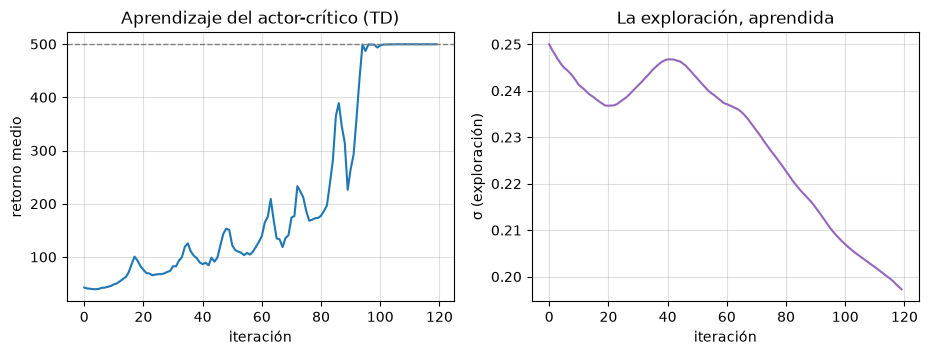

In [11]:
plt.figure(figsize=(11, 3.5))
plt.subplot(1, 2, 1)
plt.plot(historial)
plt.axhline(500, color="gray", linestyle="--", linewidth=1)
plt.xlabel("iteración")
plt.ylabel("retorno medio")
plt.title("Aprendizaje del actor-crítico (TD)")
plt.grid(True, alpha=0.4)

plt.subplot(1, 2, 2)
plt.plot(sigmas, color="tab:purple")
plt.xlabel("iteración")
plt.ylabel("σ (exploración)")
plt.title("La exploración, aprendida")
plt.grid(True, alpha=0.4)
plt.show()


**¡Aprende!** Desde ~45 puntos (el azar) hasta rozar los 500 (el máximo), con dos redes neuronales que empezaron sin saber **nada**, ni siquiera que hay que empujar hacia el lado
al que cae el palo.

Mira la curva con atención, porque cuenta una historia típica del aprendizaje por refuerzo:

- Un **arranque lento**: durante bastantes iteraciones casi no mejora. El crítico está aprendiendo a opinar, y mientras sus opiniones sean malas, las ventajas son malas.
- Una **subida** cada vez más rápida, cuando actor y crítico empiezan a entenderse.
- Una **llegada** al techo, con algún bajón por el camino.

Y a la derecha, la **σ**: la anchura de la campana, que nadie ha tocado, se ha ido **moviendo sola** según le convenía al actor. Primero baja un poco, luego vuelve a subir (hacia la iteración 40, cuando explorar más le compensaba) y al final cae de 0,25 a 0,20: al dominar la tarea, el actor
**explora menos** y afina sus empujes. Esa decisión la ha tomado el propio algoritmo.


## 12 · Mirar dentro de las redes

Como en el NB29, no nos fiamos de un número: **miramos qué ha aprendido**. Primero, el **actor**: ¿qué empuje medio da según la inclinación (con velocidad 0)? Lo comparamos con la
política del maestro que conocemos del NB18 (−30 × inclinación, recortada a ±40):


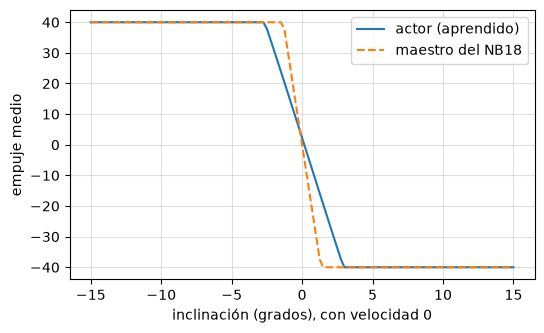

In [12]:
inclinaciones = torch.linspace(-15, 15, 121)
situaciones = torch.stack([inclinaciones, torch.zeros(121)], dim=1)
with torch.no_grad():
    empuje_actor = actor.media(situaciones).clamp(-1, 1) * 40

plt.figure(figsize=(6, 3.5))
plt.plot(inclinaciones, empuje_actor, label="actor (aprendido)")
plt.plot(inclinaciones, torch.clamp(-30 * inclinaciones, -40, 40), "--", label="maestro del NB18")
plt.xlabel("inclinación (grados), con velocidad 0")
plt.ylabel("empuje medio")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()


El actor ha descubierto **solo** la regla de oro: si el palo se inclina hacia un lado (inclinación positiva), empujar hacia el otro (empuje negativo), y más cuanto más se inclina. Y en
los extremos **satura** en ±40, como debe ser: eso, una política lineal no lo podía expresar. No es idéntico al maestro: es más **suave** (llega al tope hacia los 3°, el maestro hacia 1,3°), y no tiene por qué ser igual,
porque hay muchas formas buenas de sostener un palo. Pero la idea es la misma.

Ahora, el **crítico**. Su opinión depende de dos cosas (inclinación y velocidad, en el paso 0), así que la dibujamos como un **mapa de colores**, como el `contourf` del NB17:


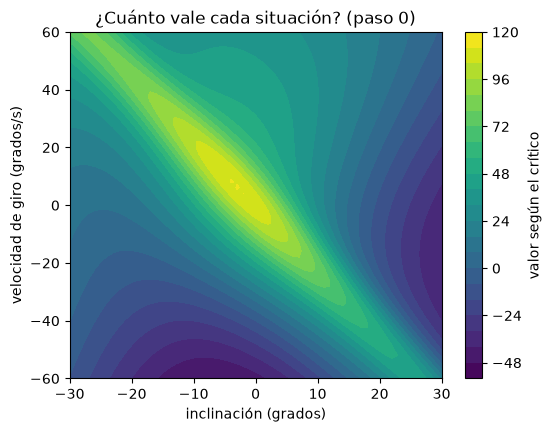

V(inclinación   2, velocidad    0) =  100.6
V(inclinación   0, velocidad    0) =  109.9
V(inclinación  15, velocidad    0) =    6.9
V(inclinación  15, velocidad   30) =   19.7
V(inclinación  15, velocidad  -30) =   58.2


In [13]:
rejilla_i, rejilla_v = torch.meshgrid(torch.linspace(-30, 30, 61), torch.linspace(-60, 60, 61), indexing="xy")
entradas = torch.stack([rejilla_i.flatten(), rejilla_v.flatten(), torch.zeros(61 * 61)], dim=1)
with torch.no_grad():
    mapa = critico(entradas).reshape(61, 61)

plt.figure(figsize=(6, 4.5))
plt.contourf(rejilla_i, rejilla_v, mapa, levels=20, cmap="viridis")
plt.colorbar(label="valor según el crítico")
plt.xlabel("inclinación (grados)")
plt.ylabel("velocidad de giro (grados/s)")
plt.title("¿Cuánto vale cada situación? (paso 0)")
plt.show()

for i, v in [(2, 0), (0, 0), (15, 0), (15, 30), (15, -30)]:
    print(f"V(inclinación {i:3d}, velocidad {v:4d}) = {critico(torch.tensor([[i, v, 0.0]])).item():6.1f}")


Mira lo que ha aprendido el crítico, **sin que le inventáramos ningún rasgo**:

- La zona **brillante** (valor alto) es una **franja diagonal** que pasa por el centro: palo casi derecho, o inclinado pero **volviendo** hacia el centro (inclinación positiva con
  velocidad negativa, o al revés).
- Las esquinas **oscuras** (valor bajo) son las situaciones perdidas: palo inclinado y **alejándose** todavía más.
- En el centro vale unos **100**: el máximo posible con γ = 0,99 (sección 7). El crítico sabe que, desde ahí, el actor ya no se cae.
- Las esquinas salen incluso **negativas**, lo cual es imposible (las recompensas nunca son negativas). Es un **disparate de extrapolación**: el palo **nunca** pasó por esas situaciones durante el
  entrenamiento, así que el crítico no tenía ejemplos y "se inventa" lo que sale de prolongar su red. Una red solo sabe de lo que ha visto (NB19). Recuérdalo siempre.
- Fíjate en los números: con 15° de inclinación, la situación vale muchísimo más si el palo **vuelve** (velocidad −30) que si **se va** (velocidad +30). Lo mismo que intuimos en el NB30, pero ahora
  lo ha descubierto una red sola.

## 13 · El examen: el entorno oficial

Hasta ahora hemos entrenado con nuestra simulación vectorizada. El examen de verdad es en el **entorno oficial de Gymnasium** que construimos en el NB25, `PaloDeEscoba-v0`, que pasa
el verificador `check_env`. Lo traemos tal cual (la misma clase del NB25) y lo registramos:


In [14]:
import gymnasium as gym
from gymnasium import spaces

class PaloDeEscobaEnv(gym.Env):
    def __init__(self, viento_maximo=30.0):
        super().__init__()
        self.viento_maximo = viento_maximo
        self.empuje_maximo = 40.0
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(2,), dtype=np.float32)
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        self.inclinacion = 0.0
        self.velocidad = 0.0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.inclinacion = 2.0
        self.velocidad = 0.0
        return self._observacion(), {}

    def step(self, action):
        empuje = float(np.clip(action[0], -1.0, 1.0)) * self.empuje_maximo
        viento = self.np_random.uniform(-self.viento_maximo, self.viento_maximo)
        aceleracion = 10 * self.inclinacion + empuje + viento
        self.velocidad = self.velocidad + aceleracion * 0.02
        self.inclinacion = self.inclinacion + self.velocidad * 0.02
        terminado = bool(abs(self.inclinacion) > 30)
        recompensa = 0.0 if terminado else float(1 - (self.inclinacion / 30) ** 2)
        return self._observacion(), recompensa, terminado, False, {"viento": viento}

    def _observacion(self):
        return np.array([self.inclinacion, self.velocidad], dtype=np.float32)

gym.register(id="PaloDeEscoba-v0", entry_point=PaloDeEscobaEnv, max_episode_steps=500)


Una decisión importante: en el examen, ¿el actor sigue **sorteando** acciones de su campana, o usa directamente la **media**? Durante el entrenamiento, el ruido sirve para **explorar**.
Pero a la hora de **trabajar**, lo habitual es usar la **media**, la acción que el actor considera mejor, sin ruido. A eso se le llama política **determinista** (sin azar). Probamos las dos,
con 20 episodios cada una, con semillas de viento que el actor nunca ha visto (de la 1000 en adelante):


In [15]:
def examen(actor, n_episodios=20, determinista=True, viento_maximo=30.0):
    entorno = gym.make("PaloDeEscoba-v0", viento_maximo=viento_maximo)
    generador = np.random.default_rng(123)
    retornos = []
    for episodio in range(n_episodios):
        observacion, info = entorno.reset(seed=1000 + episodio)
        retorno, terminado, truncado = 0.0, False, False
        while not (terminado or truncado):
            with torch.no_grad():
                media = actor.media(torch.from_numpy(observacion)).item()
            accion = media if determinista else media + actor.log_sigma.exp().item() * generador.standard_normal()
            observacion, recompensa, terminado, truncado, info = entorno.step(np.array([accion]))
            retorno += recompensa
        retornos.append(retorno)
    return np.array(retornos)

for determinista in [True, False]:
    r = examen(actor, determinista=determinista)
    print(f"{'media (determinista)' if determinista else 'sorteando (estocástica)':>24}: retorno medio {r.mean():6.1f} | peor {r.min():6.1f} | caídas {(r < 400).sum()} de 20")


    media (determinista): retorno medio  499.6 | peor  499.3 | caídas 0 de 20


 sorteando (estocástica): retorno medio  499.6 | peor  499.3 | caídas 0 de 20


El actor aprueba con nota en el entorno oficial, con vientos que nunca había visto. Y usando la media, sin ruido, lo hace al menos igual de bien: el ruido era para **aprender**, no para **trabajar**.

(Fíjate en lo que acabamos de hacer: entrenar en una simulación y examinar en **otra** implementación de la misma física. En robótica real, el "otro entorno" será el **robot de verdad**, y la
diferencia entre ambos, el famoso **reality gap** del NB02.)

## 14 · ¿Ha sido suerte? Montecarlo contra diferencia temporal

Ya sabes la regla de oro desde el NB29: **un solo entrenamiento no demuestra nada**. Vamos a entrenar 4 veces con cada tipo de ventaja (semillas 0 a 3) y a mirar en qué iteración supera
cada uno los 490 puntos, y con cuánto termina (la media de las 5 últimas iteraciones). **Ojo: esta celda tarda unos 4 minutos** en la Raspberry Pi (son 8 entrenamientos). Buen momento
para un vaso de agua.


In [16]:
def primera_por_encima(historial, umbral=490):
    return next((i for i, x in enumerate(historial) if x > umbral), None)

curvas = {}
for modo in ["montecarlo", "td"]:
    curvas[modo] = []
    for semilla in range(4):
        _, _, h, _ = entrenar(modo, semilla=semilla)
        curvas[modo].append(h)
    llegadas = [primera_por_encima(h) for h in curvas[modo]]
    finales = [round(float(np.mean(h[-5:]))) for h in curvas[modo]]
    print(f"{modo:>10}: supera 490 en las iteraciones {llegadas} | termina en {finales}")


montecarlo: supera 490 en las iteraciones [None, 116, 100, 109] | termina en [213, 494, 494, 496]


        td: supera 490 en las iteraciones [94, 93, 92, 78] | termina en [500, 493, 499, 498]


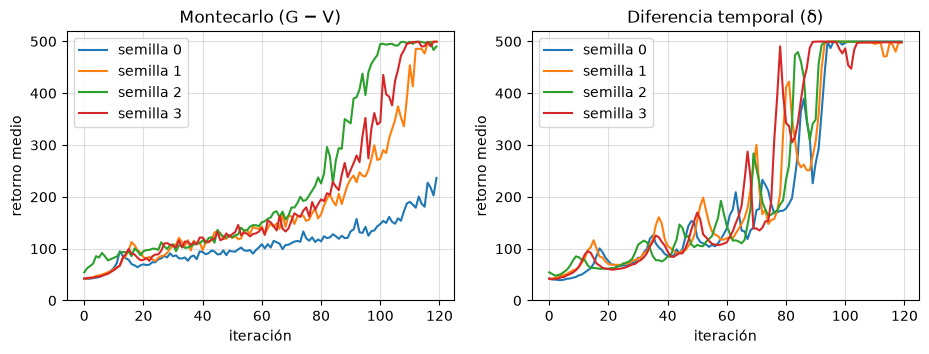

In [17]:
plt.figure(figsize=(11, 3.5))
for k, modo in enumerate(["montecarlo", "td"]):
    plt.subplot(1, 2, k + 1)
    for semilla, h in enumerate(curvas[modo]):
        plt.plot(h, label=f"semilla {semilla}")
    plt.title("Montecarlo (G − V)" if modo == "montecarlo" else "Diferencia temporal (δ)")
    plt.xlabel("iteración")
    plt.ylabel("retorno medio")
    plt.ylim(0, 520)
    plt.grid(True, alpha=0.4)
    plt.legend()
plt.show()


Mira las dos gráficas con ojos de ingeniero (las cifras exactas dependen de la semilla; lo que importa es el patrón):

- Con **diferencia temporal**, las cuatro semillas llegan arriba, y en iteraciones **parecidas** (entre la 78 y la 94): es el método más **fiable** aquí.
- Con **Montecarlo**, la subida es más lenta: las semillas que llegan lo hacen más tarde (más allá de la iteración 100), y la semilla 0 se queda **muy** atrás (unos 210 puntos al final). Las ventajas
  con tanto ruido (NB30) empujan en la buena dirección solo "en promedio", y eso se paga en tiempo y en desigualdad entre semillas.
- Curiosamente, las curvas de Montecarlo son más **lisas** y las de TD, más **nerviosas**, con subidas bruscas y algún bajón. Ojo con juzgar un método por lo bonita que es su curva: lo que importa
  es a dónde llega y con qué fiabilidad.

Es un resultado de **este** problema, no una ley universal: con un crítico malo, la diferencia temporal hereda sus errores (el **sesgo**), y hay problemas donde Montecarlo gana. Por eso los
algoritmos modernos no eligen un extremo, sino un **punto intermedio** con un mando (lo verás en el NB33).

### La parte fea: la fragilidad

Si miras las curvas con lupa verás algo inquietante: **bajones**. Hay iteraciones en las que un actor que ya sabía sostener el palo **empeora de golpe**, a veces mucho. Y si probaras tasas de
aprendizaje más altas (ejercicio E4), lo verías a lo grande: actores que llegan a 500 y unas iteraciones después **se derrumban** a 80 y no se recuperan.

¿Por qué pasa? Por cómo da los pasos **Adam** (NB31): tiene una tasa a medida para cada ruedecilla, de modo que **el tamaño de sus pasos no depende mucho de lo grande que sea la pendiente**.
Cuando el actor ya es bueno y casi todos los episodios llegan a 500, las ventajas son casi todo **ruido**... pero al **normalizarlas** (dividir por su desviación, NB30) las inflamos hasta
tamaño 1, y Adam da pasos de tamaño normal en direcciones **al azar**. Un paso desafortunado basta para estropear una política que funcionaba, y como el actor solo aprende de lo que **él
mismo** juega, una política estropeada genera datos malos, que la estropean más. Es una **espiral**.

Esta es **la** gran debilidad de los métodos de gradiente de política, y la razón por la que existe el algoritmo que veremos en la próxima lección: **PPO**, cuya idea central es,
precisamente, **no dejar que la política cambie demasiado de un paso al siguiente**.

Mientras tanto, el truco de ingeniero para protegerte es sencillo: **guarda la mejor versión** del actor que hayas visto durante el entrenamiento, no solo la última.


## 15 · Guardar el actor

Como en el NB31: `state_dict` y `torch.save`. Guardamos las dos redes del entrenamiento de la sección 11, y comprobamos que el actor cargado da exactamente las mismas medias:


In [18]:
from pathlib import Path

carpeta = Path("practica_nb32")
carpeta.mkdir(exist_ok=True)
torch.save(actor.state_dict(), carpeta / "actor_palo.pt")
torch.save(critico.state_dict(), carpeta / "critico_palo.pt")

actor_cargado = Actor()
actor_cargado.load_state_dict(torch.load(carpeta / "actor_palo.pt", weights_only=True))
with torch.no_grad():
    print("¿Igual que el original?", torch.allclose(actor_cargado.media(situaciones), actor.media(situaciones)))
    print("σ cargada:", round(actor_cargado.log_sigma.exp().item(), 3))


¿Igual que el original? True
σ cargada: 0.197


Fíjate en que `log_sigma` viaja también en el `state_dict`: al ser un `nn.Parameter`, es una ruedecilla oficial de la red.

## 16 · Resumen de la lección

1. **Actor-crítico**: dos redes que aprenden juntas. El **actor** (la política) decide; el **crítico** (la función de valor) predice cuánto vale cada situación. La ventaja = lo que pasó − lo
   que el crítico esperaba.
2. Las **redes** pueden expresar políticas que **saturan** y descubren solas los rasgos que el crítico del NB30 necesitaba inventados a mano.
3. La **pérdida truco** del actor, **−media(log-prob × ventaja)**: bajarla con PyTorch = subir la dirección de mejora del NB29 (comprobado con números). Su valor no significa nada; solo su pendiente.
4. Detalles prácticos: **escalar** entradas y salidas; aprender **log σ** (y σ = e^(log σ), siempre positiva): el robot decide cuánto explorar.
5. La **diferencia temporal**: δ = r + γ·V(siguiente) − V(ahora). Juzgar un paso **sin esperar al final**, fiándose del crítico: **menos ruido**, algo de **sesgo**. Aquí, más fiable que Montecarlo.
6. Entrenado desde cero: de ~45 a ~500 en el palo de escoba; aprueba en el entorno oficial `PaloDeEscoba-v0` con la política **determinista** (la media).
7. La **fragilidad**: Adam + ventajas normalizadas dan pasos de tamaño fijo incluso cuando solo hay ruido; un mal paso puede **derrumbar** la política. Protección: guardar la mejor versión. Solución
   de fondo: **PPO**.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Actor** | La red que decide las acciones (la política). |
| **Crítico** | La red que predice el valor de cada situación. |
| **Actor-crítico** | El algoritmo en el que actor y crítico aprenden juntos. |
| **Pérdida del actor** | −media(log-prob × ventaja): un truco para que PyTorch suba la dirección de mejora. |
| **Diferencia temporal (TD), δ** | r + γ·V(siguiente) − V(ahora): la sorpresa de un solo paso. |
| **Montecarlo** | Juzgar con el retorno completo, esperando al final del episodio. |
| **Sesgo** | Un error sistemático (aquí, el que hereda la ventaja si el crítico se equivoca). |
| **Equilibrio ruido-sesgo** | Menos ruido suele costar más sesgo, y al revés. |
| **`nn.Tanh`** | Activación con forma de S suave, entre −1 y 1. |
| **`nn.Parameter`** | Un tensor convertido en ruedecilla oficial de la red. |
| **log σ** | La forma de aprender σ sin que pueda volverse negativa. |
| **Política determinista** | Usar la acción media, sin sorteo (para trabajar, no para aprender). |


## 17 · Ejercicios

**E1.** En la comprobación de la sección 3, cambia la ventaja de +2 a −2. ¿Qué le pasa a la pendiente? ¿Hacia dónde se moverá ahora la media de la campana? ¿Por qué tiene sentido?

**E2.** Calcula a mano δ para este paso: el crítico decía V(ahora) = 80; el paso dio una recompensa r = 0,9; en la situación siguiente, el crítico dice V(siguiente) = 85; γ = 0,99.
¿Salió mejor o peor de lo esperado? ¿Y si el palo se hubiera caído en ese paso (recompensa 0)?

**E3.** ¿Por qué el actor **no** necesita el reloj como entrada, y el crítico **sí**?

**E4.** Entrena con la diferencia temporal, semilla 0, pero con `tasa_actor=0.03` (seis veces mayor) y 60 iteraciones. Dibuja la curva. ¿Qué pasa?

**E5.** Examina al actor entrenado con **más viento** del que vio al entrenar (±30): prueba `examen(actor, viento_maximo=v)` con v = 60, 80, 100, 120 y 150. ¿Hasta dónde aguanta?

**E6.** Modifica `entrenar` para que **guarde la mejor versión** del actor: cada vez que el retorno medio de una iteración supere al mejor visto, copia su `state_dict`. (Pista: `copy.deepcopy`, NB21.)

**E7.** **Reto.** Entrena **sin** que σ aprenda: congela la ruedecilla con `actor.log_sigma.requires_grad_(False)` justo después de crearla (dentro de `entrenar`). ¿Cambia el resultado? Mira la curva de σ del
apartado 11 para razonarlo.


<details>
<summary>▶ Solución E1</summary>

La pendiente cambia de signo: pasa a ser (0,48, 0,24) en vez de (−0,48, −0,24). El optimizador va en contra de la pendiente, así que ahora los pesos se mueven para **bajar** la media, alejándola de −10
(hacia −13 y más allá). Tiene todo el sentido: ventaja negativa = la acción −10 salió **peor** de lo esperado, así que hay que hacerla **menos** probable, alejando de ella el centro de la campana.
</details>

<details>
<summary>▶ Solución E2</summary>

δ = 0,9 + 0,99 × 85 − 80 = 0,9 + 84,15 − 80 = **5,05**. Positiva: el paso salió **mejor** de lo esperado (llegamos a una situación mejor que la de partida), así que la acción se reforzará.

Si el palo se hubiera caído: r = 0 y no hay situación siguiente (su valor es 0): δ = 0 + 0 − 80 = **−80**. Muy negativa: esa acción condujo al desastre, y se debilitará con fuerza.
</details>

<details>
<summary>▶ Solución E3</summary>

El **actor** decide **cómo empujar**, y la forma correcta de sostener un palo es la misma en el paso 10 que en el 400: solo depende de la inclinación y la velocidad. El **crítico**, en cambio,
predice **cuántas recompensas quedan**, y eso sí depende del reloj: en el paso 10 quedan hasta 490 recompensas por ganar; en el 490, como mucho 10. Sin el reloj, el crítico vería dos situaciones
idénticas con retornos muy distintos y no sabría qué predecir.
</details>

<details>
<summary>▶ Solución E4</summary>

```python
_, _, h_rapido, _ = entrenar("td", semilla=0, iteraciones=60, tasa_actor=0.03)
plt.plot(h_rapido); plt.grid(True, alpha=0.4); plt.show()
```

Con la tasa grande el actor sube **mucho más deprisa** (con la semilla 0 llega a ~499 hacia la iteración 30)... y después **se derrumba**: unas pocas iteraciones más tarde el retorno cae a ~110, luego a
~60, y no se recupera en lo que queda de entrenamiento. Es la fragilidad de la sección 14, a lo grande: pasos demasiado grandes cuando ya no hay nada que aprender destrozan la política. Ganar velocidad a costa de estabilidad
es la tentación permanente del RL, y la razón de ser de PPO.
</details>

<details>
<summary>▶ Solución E5</summary>

```python
for viento in [60, 80, 100, 120, 150]:
    r = examen(actor, viento_maximo=viento)
    print(viento, r.mean().round(1), (r < 400).sum())
```

Sorprendentemente bien: con viento **±60**, el doble del que vio, sigue sin caerse ni una vez (≈499). Con ±80 empieza a fallar (2 caídas de 20), con ±100 cae en 7 de 20, con ±120 en 14, y con ±150
en 19 de 20: el empuje máximo (±40) ya no basta contra esas ráfagas. Ha aprendido algo **robusto**, que funciona más allá de lo que vio, pero tiene un límite. Es lo que se llama
**generalizar** fuera de lo visto en el entrenamiento, y por eso en robótica se entrena con **condiciones variadas** (aleatorizar el mundo, NB02): para que el robot no se encuentre sorpresas.
</details>

<details>
<summary>▶ Solución E6</summary>

Dentro de `entrenar`, antes del bucle: `mejor_retorno, mejor_estado = -1.0, None`. Y justo después de apuntar el historial:

```python
import copy
if historial[-1] > mejor_retorno:
    mejor_retorno = historial[-1]
    mejor_estado = copy.deepcopy(actor.state_dict())
```

Al final, `actor.load_state_dict(mejor_estado)` antes de devolverlo. Hace falta `deepcopy` porque `state_dict()` devuelve los **mismos** tensores que la red está usando (vistas, NB27): sin copiarlos,
tu "mejor versión" cambiaría con cada paso de entrenamiento.
</details>

<details>
<summary>▶ Solución E7</summary>

```python
# dentro de entrenar, después de actor, critico = Actor(), Critico():
actor.log_sigma.requires_grad_(False)
```

En este problema el efecto es pequeño: durante el entrenamiento normal σ solo baja de 0,25 a 0,20 (mira la gráfica), así que congelarla no cambia gran cosa. Medido: con σ congelada en 0,25, las semillas 0, 1 y 2 superan los 490 en las iteraciones 93, 90 y 84 (con σ aprendible: 94, 93
y 92). Es una lección útil: una
ruedecilla aprendible **no siempre** aprende mucho; si la tarea no le da motivo, se mueve poco. En problemas más difíciles (como el humanoide), σ sí cambia mucho, y aprenderla es clave.
</details>


## 18 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Hoy has construido, desde cero, la arquitectura que mueve a los robots que andan en los vídeos de investigación: un **actor** y un **crítico**, dos redes neuronales que aprenden juntas. Y
has visto su talón de Aquiles: la **fragilidad**. En la próxima lección, **PPO** (*Proximal Policy Optimization*, "optimización de la política en pasos próximos"), el algoritmo más usado del
mundo para entrenar robots. Su idea es casi de sentido común: aprovechar cada lote de episodios **varias veces**, pero **sin dejar** que la política se aleje demasiado de la que jugó. Con él,
y con un mando para elegir entre ruido y sesgo (GAE), tendrás en las manos la herramienta con la que se entrenan los humanoides de verdad.
